In [174]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from model.model import MLP
from src.model import VQVAE
import yaml
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
import umap
from sklearn.cluster import AgglomerativeClustering


In [175]:
# config.yaml ファイルのパス
config_file_path = '/workspace/inhouse-vqvae/VQVAE/config/model/model.yaml'

try:
    with open(config_file_path, 'r') as file:
        config = yaml.safe_load(file)
        print("config.yamlを正常に読み込みました。")

    # # 読み込んだ情報の参照
    # # データベースのユーザー名を参照
    # db_user = config['database']['user']
    # print(f"データベースのユーザー名: {db_user}")

    # # モデルのパラメータを参照
    # model_name = config['model']['name']
    # n_estimators = config['model']['parameters']['n_estimators']

    # print(f"使用するモデル: {model_name}")
    # print(f"n_estimators: {n_estimators}")

except FileNotFoundError:
    print(f"エラー: '{config_file_path}' が見つかりません。ファイルパスを確認してください。")
except Exception as e:
    print(f"エラーが発生しました: {e}")

config.yamlを正常に読み込みました。


### ランダム乱数生成、実行例として用いる

In [42]:
# 256本の64次元ベクトルをtorch.tensorとして作成
# 実際のデータに置き換えてください
X_torch = torch.randn(256, 64)

# scikit-learnのために、データをNumPy配列に変換
X_np = X_torch.numpy()

print(f"データの形状: {X_np.shape}")

データの形状: (256, 64)


### MLPから持ってくる、MH学習済みのものとかで使う

In [201]:
# チェックポイントファイルをロード
checkpoint = torch.load('/workspace/inhouse-vqvae/VQVAE/mlp_mnist_adam25.pth', weights_only=True)

# 'codebook'キーから直接アクセス
codebook_tensor = checkpoint['codebook']

print(f"Codebookの形状: {codebook_tensor.shape}")
print("Codebookへのアクセスに成功しました。")

X_np = codebook_tensor.cpu().numpy()

print(f"データの形状: {X_np.shape}")

Codebookの形状: torch.Size([256, 64])
Codebookへのアクセスに成功しました。
データの形状: (256, 64)


### VQVAEから持ってくる、再構成時点でのデータにアクセスできる

In [170]:
model = VQVAE(**config)
checkpoint = torch.load('VQVAE_local_adam_25.pth', weights_only=True)
model.load_state_dict(checkpoint['param'])
X_torch = model.vector_quantization.embedding.weight

# scikit-learnのために、データをNumPy配列に変換
X_np = X_torch.detach().numpy()

print(f"データの形状: {X_np.shape}")

データの形状: (256, 64)


# 二次元平面への可視化

### PCAによる可視化、点がかぶるため微小ズレを加えた可視化も

PCAによる次元削減と可視化を実行中...


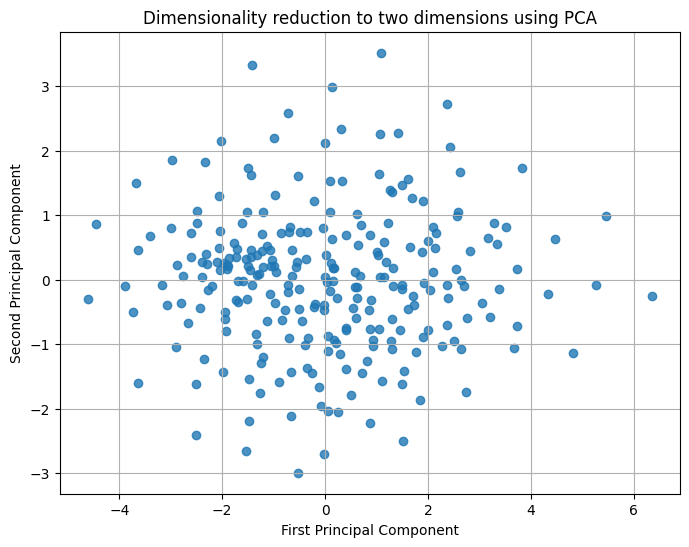

PCAの処理が完了しました。


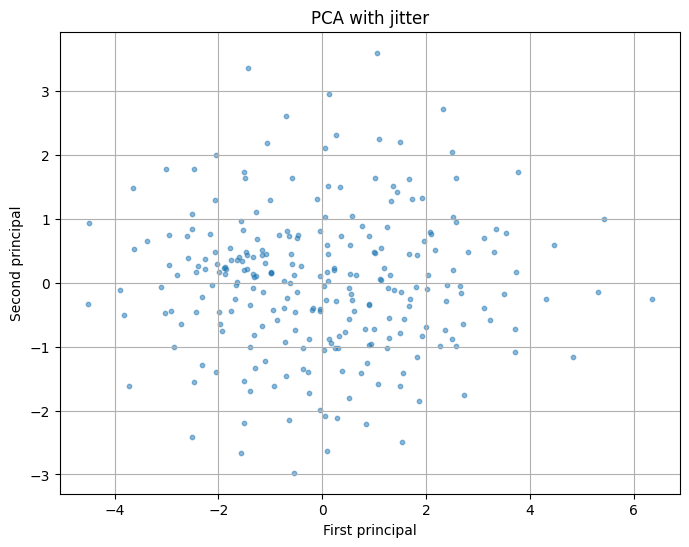

In [202]:
print("PCAによる次元削減と可視化を実行中...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_np)

# 結果の可視化
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.8)
plt.title('Dimensionality reduction to two dimensions using PCA')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.grid(True)
plt.show()

print("PCAの処理が完了しました。")

noise_amount = 0.05
X_pca_jittered = X_pca + np.random.randn(X_pca.shape[0], X_pca.shape[1]) * noise_amount

plt.figure(figsize=(8, 6))
# sで点のサイズ、alphaで透明度を調整
plt.scatter(X_pca_jittered[:, 0], X_pca_jittered[:, 1], alpha=0.5, s=10)
plt.title('PCA with jitter')
plt.xlabel('First principal')
plt.ylabel('Second principal')
plt.grid(True)
plt.savefig('pca_jitter_plot.png')

### t-SNEによる可視化

t-SNEによる次元削減と可視化を実行中...


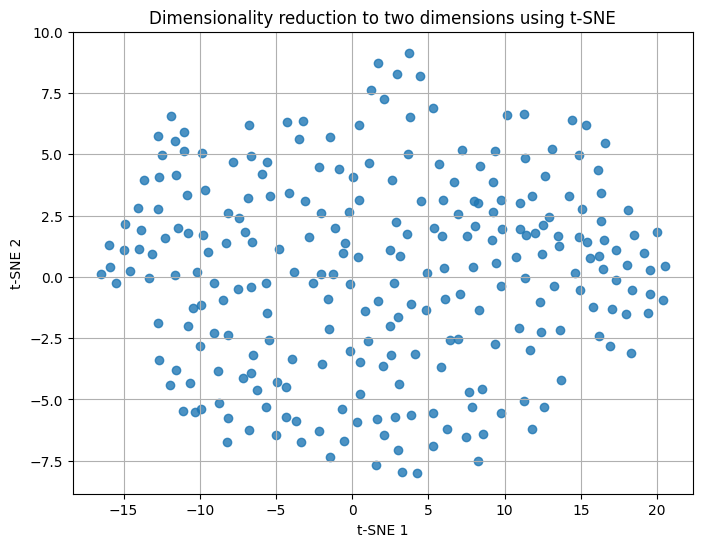

t-SNEの処理が完了しました。


In [195]:
print("t-SNEによる次元削減と可視化を実行中...")
tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_np)

# 結果の可視化
plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.8)
plt.title('Dimensionality reduction to two dimensions using t-SNE')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.grid(True)
plt.show()

print("t-SNEの処理が完了しました。")

### UMAPによる可視化

UMAPによる次元削減と可視化を実行中...


/opt/patho/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


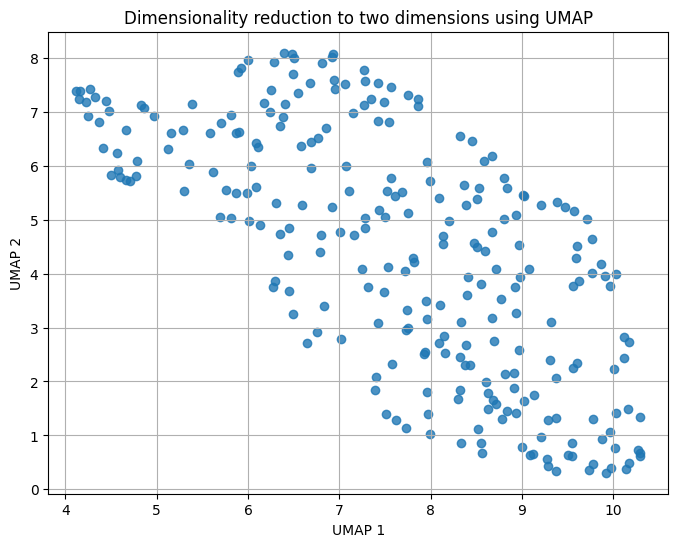

UMAPの処理が完了しました。


In [196]:
# サンプルデータの作成 (ご自身のデータに置き換えてください)

# --- UMAPによる次元削減と可視化 ---
print("UMAPによる次元削減と可視化を実行中...")
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_np)

# 結果の可視化
plt.figure(figsize=(8, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], alpha=0.8)
plt.title('Dimensionality reduction to two dimensions using UMAP')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.grid(True)
plt.show()

print("UMAPの処理が完了しました。")

# Kmeans によるクラスタリング

### エルボー法によるクラスター数の推定

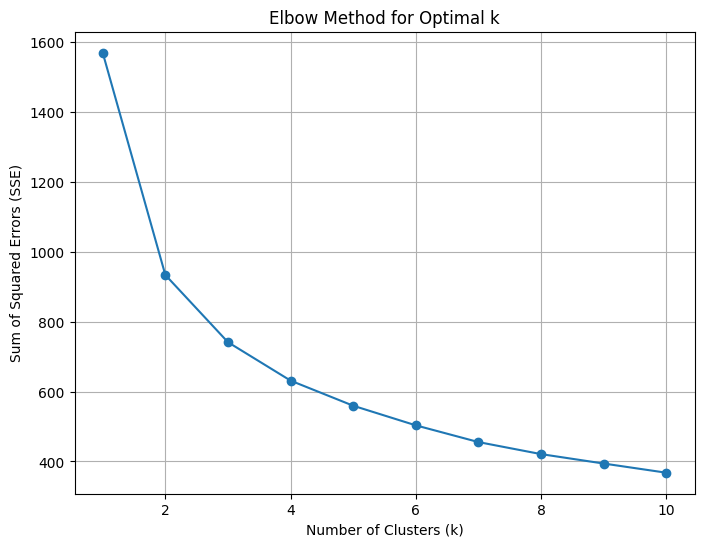

グラフを見て、SSEの減少が鈍化し始める点（肘）を見つけてください。それが最適なクラスター数です。


In [203]:
# SSEを格納するリスト
sse = []
# 試行するクラスター数の範囲
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_np)
    # inertia_ はSSEに相当します
    sse.append(kmeans.inertia_)

# グラフのプロット
plt.figure(figsize=(8, 6))
plt.plot(k_range, sse, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.grid(True)
plt.show()

print("グラフを見て、SSEの減少が鈍化し始める点（肘）を見つけてください。それが最適なクラスター数です。")

### クラスタリングと可視化

k-meansクラスタリングが完了しました。
各データポイントのクラスターラベル: [0 2 0 1 0 2 2 2 2 2]...


/opt/patho/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


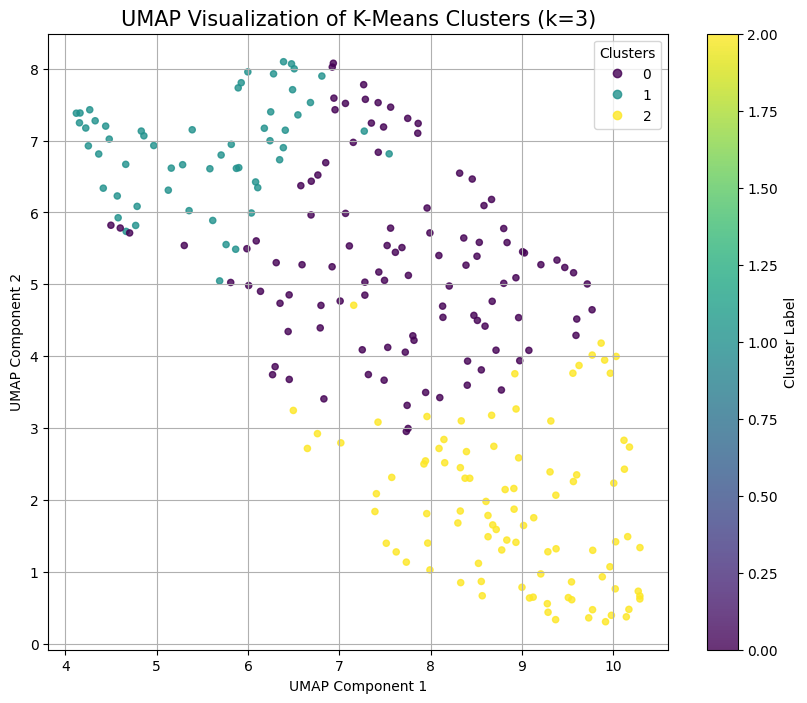

UMAPによる可視化が完了しました。


In [204]:
# 推定したクラスター数を入力
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)

# クラスタリングを実行
kmeans.fit(X_np)

# 各データポイントがどのクラスターに属するかを取得
cluster_labels = kmeans.labels_

print("k-meansクラスタリングが完了しました。")
print(f"各データポイントのクラスターラベル: {cluster_labels[:10]}...")

# UMAPのインスタンスを作成
reducer = umap.UMAP(n_components=2, random_state=42)

# 次元削減を実行
X_umap = reducer.fit_transform(X_np)

# 可視化
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=cluster_labels, cmap='viridis', s=20, alpha=0.8)
plt.title(f'UMAP Visualization of K-Means Clusters (k={n_clusters})', fontsize=15)
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.grid(True)

# カラーバーと凡例を追加
plt.colorbar(scatter, label='Cluster Label')
plt.legend(*scatter.legend_elements(), title='Clusters')
plt.show()

print("UMAPによる可視化が完了しました。")

### 階層的クラスタリング

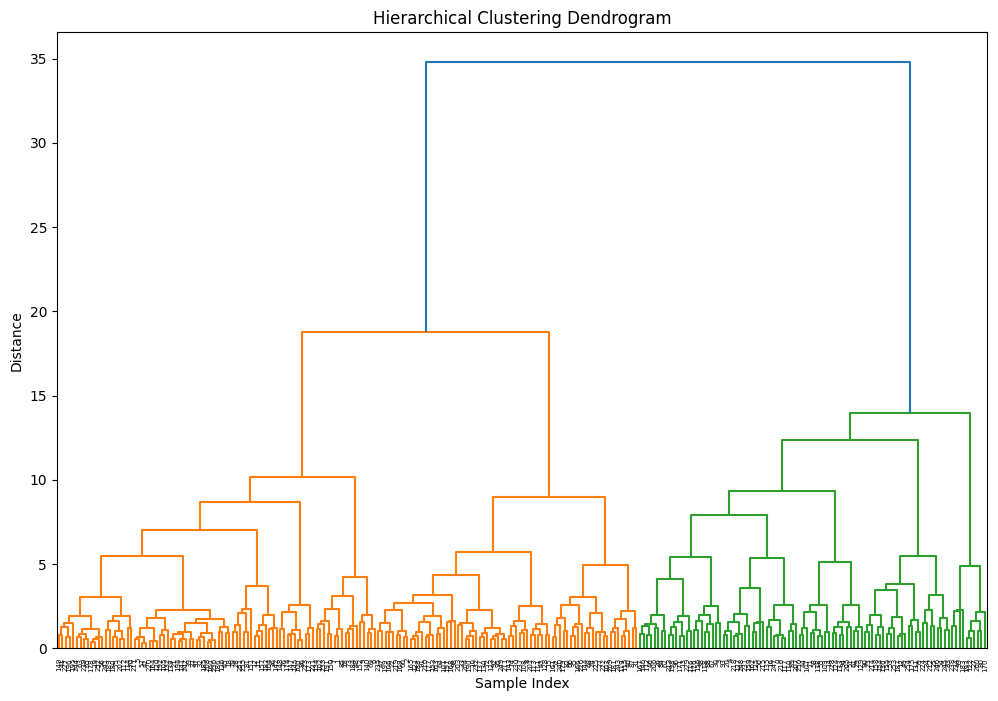

デンドログラムが作成されました。グラフを見て、縦の線が最も長く、かつ次の統合までの距離が長いところを探してください。その点が最適なクラスター数を示唆します。


In [200]:
# linkage関数を使ってクラスタリングの階層構造を計算
# method='ward'は、クラスター内の分散を最小化する方法
linked = linkage(X_np, method='ward')

# デンドログラムをプロット
plt.figure(figsize=(12, 8))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

print("デンドログラムが作成されました。グラフを見て、縦の線が最も長く、かつ次の統合までの距離が長いところを探してください。その点が最適なクラスター数を示唆します。")

/opt/patho/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


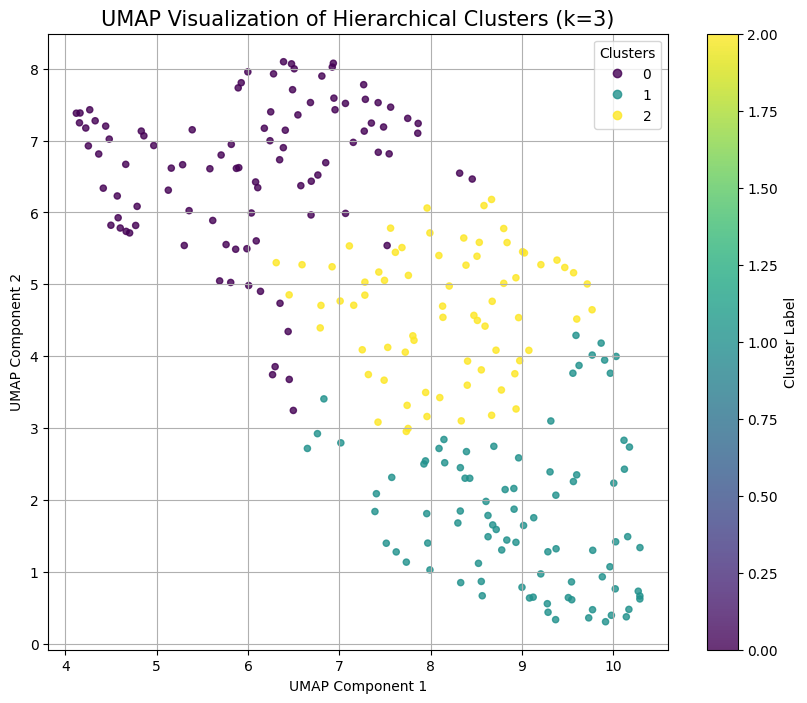

階層的クラスタリングとUMAPによる可視化が完了しました。


In [199]:
# デンドログラムで判断したクラスター数を設定
n_clusters_hierarchical = 3
agg_clustering = AgglomerativeClustering(n_clusters=n_clusters_hierarchical, linkage='ward')

# クラスタリングを実行
hierarchical_labels = agg_clustering.fit_predict(X_np)

# UMAPで次元削減
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_np)

# 可視化
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=hierarchical_labels, cmap='viridis', s=20, alpha=0.8)
plt.title(f'UMAP Visualization of Hierarchical Clusters (k={n_clusters_hierarchical})', fontsize=15)
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.grid(True)
plt.colorbar(scatter, label='Cluster Label')
plt.legend(*scatter.legend_elements(), title='Clusters')
plt.show()

print("階層的クラスタリングとUMAPによる可視化が完了しました。")

/opt/patho/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


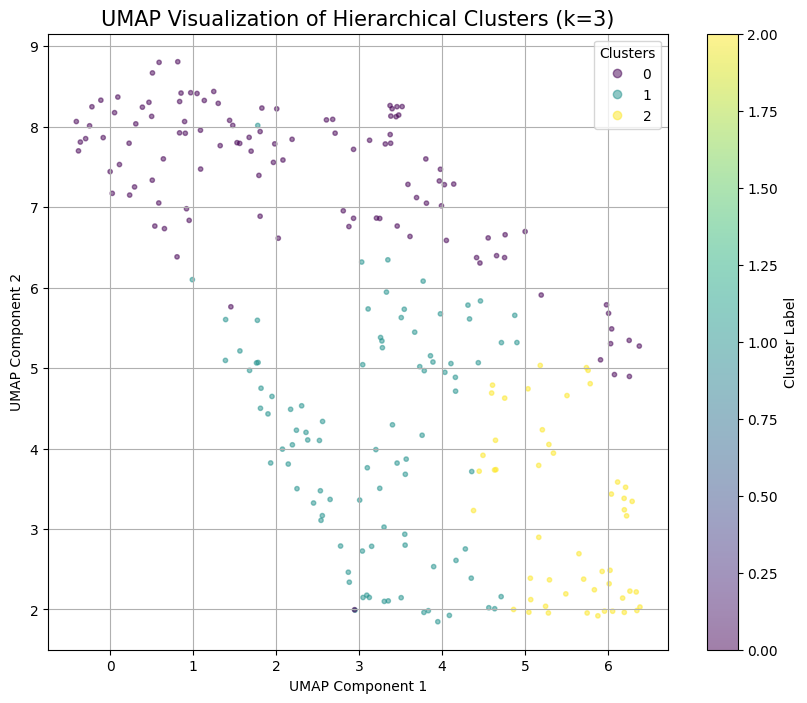

階層的クラスタリングとUMAPによる可視化が完了しました。


In [185]:
# デンドログラムで判断したクラスター数を設定
n_clusters_hierarchical = 3
agg_clustering = AgglomerativeClustering(n_clusters=n_clusters_hierarchical, linkage='ward')

# クラスタリングを実行
hierarchical_labels = agg_clustering.fit_predict(X_np)

# UMAPで次元削減
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_np)
X_umap_jittered = X_umap + np.random.randn(X_pca.shape[0], X_pca.shape[1]) * noise_amount

# 可視化
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_umap_jittered[:, 0], X_umap_jittered[:, 1], c=hierarchical_labels, cmap='viridis', s=10, alpha=0.5)
plt.title(f'UMAP Visualization of Hierarchical Clusters (k={n_clusters_hierarchical})', fontsize=15)
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.grid(True)
plt.colorbar(scatter, label='Cluster Label')
plt.legend(*scatter.legend_elements(), title='Clusters')
plt.show()

print("階層的クラスタリングとUMAPによる可視化が完了しました。")